In [ ]:


from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression, Ridge, LassoCV,ElasticNetCV
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut, cross_val_score
from sklearn.feature_selection import SelectKBest, f_regression, VarianceThreshold, mutual_info_regression
from sklearn.linear_model import Ridge
import numpy as np
#from torchvision import transforms
import pandas as pd
import os
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
import numpy.linalg as la
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import DataConversionWarning
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch._dynamo as dynamo

dynamo.config.suppress_errors = True
dynamo.disable()
warnings.filterwarnings("ignore", category=DataConversionWarning)

   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
    --------------------------------------- 0.1/7.0 MB 5.5 MB/s eta 0:00:02
   - -------------------------------------- 0.2/7.0 MB 2.3 MB/s eta 0:00:03
   --- ------------------------------------ 0.6/7.0 MB 4.5 MB/s eta 0:00:02
   ---- ----------------------------------- 0.8/7.0 MB 4.3 MB/s eta 0:00:02
   ----- ---------------------------------- 0.9/7.0 MB 3.9 MB/s eta 0:00:02
   ----- ---------------------------------- 1.0/7.0 MB 2.9 MB/s eta 0:00:03
   ------ --------------------------------- 1.1/7.0 MB 2.8 MB/s eta 0:00:03
   ---------- ----------------------------- 1.8/7.0 MB 3.7 MB/s eta 0:00:02
   ----------- ---------------------------- 1.9/7.0 MB 3.4 MB/s eta 0:00:02
   ------------ --------------------------- 2.1/7.0 MB 3.4 MB/s eta 0:00:02
   ------------- -------------------------- 2.3/7.0 MB 3.3 MB/s eta 0:00:02
   ---------------- ----------------------- 2.8/7.0 MB 3.7 MB/s eta 0:00:02
   ----------------


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/115.4 kB ? eta -:--:--
     -------------------------------------- 115.4/115.4 kB 3.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 11.1 MB/s eta 0:00:01
   ---- ----------------------------------- 0.9/8.1 MB 11.7 MB/s eta 0:00:01
   -------- ------------------------------- 1.8/8.1 MB 11.2 MB/s eta 0:00:01
   ---------- ----------------------------- 2.1/8.1 MB 11.1 MB/s eta 0:00:01
   -------------- ------------------------- 2.9/8.1 MB 10.4 MB/s eta 0:00:01
   ----------------- ---------------------- 3.5/8.1 MB 10.8 MB/s eta 0:00:01
   --------------------- ------------------ 4.4/8.1 MB 10.5 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 10.0 MB/s eta 0:00:01
   ------------------------- -------------- 5.1/8.1 MB 9.8 MB/s eta 0:00:01
   -------------------


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
data_path = "data/data_labeled" 

In [11]:
X_train = pd.read_csv(f"{data_path}/X_train.csv")
y_train = pd.read_csv(f"{data_path}/y_train.csv", header=None, names=["risk"])["risk"]
X_test = pd.read_csv(f"{data_path}/X_test.csv")
y_test = pd.read_csv(f"{data_path}/y_test.csv", header=None, names=["risk"])["risk"]

In [12]:
img_train_files = X_train["img_filename"].values
img_test_files  = X_test["img_filename"].values
X_train = X_train.drop(columns=["img_filename"])  
X_test = X_test.drop(columns=["img_filename"])

In [13]:
num_features = ['age','blood pressure',  'calcium', 'cholesterol', 
                 'hemoglobin', 'height', 'potassium', 'vitamin D', 'weight']

In [14]:
cat_features = ['profession', 'sarsaparilla', 'smurfberry liquor', 'smurfin donuts']

======================
1 pré-traitement des données
======================

In [15]:
# 1.1 Gestion des doublons
print("\n=== Gestion des doublons ===")
duplicates = X_train[X_train.duplicated(keep=False)]
print(f"Nombre de doublons avant suppression : {len(duplicates)}")
X_train = X_train.drop_duplicates()
print(f"Nombre de lignes après suppression des doublons : {len(X_train)}")


=== Gestion des doublons ===
Nombre de doublons avant suppression : 0
Nombre de lignes après suppression des doublons : 1000


In [16]:
# 1.2 Gestion des valeurs manquantes
print("\n=== Gestion des valeurs manquantes ===")
print("Valeurs manquantes avant traitement:")
print(X_train.isnull().sum())


=== Gestion des valeurs manquantes ===
Valeurs manquantes avant traitement:
age                  0
blood pressure       0
calcium              0
cholesterol          0
hemoglobin           0
height               0
potassium            0
profession           0
sarsaparilla         0
smurfberry liquor    0
smurfin donuts       0
vitamin D            0
weight               0
dtype: int64


In [17]:
# Imputation des valeurs manquantes
for col in num_features:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)  # Using train median for test set

In [18]:
for col in cat_features:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)  # Using train mode for test set

In [19]:
print("\nValeurs manquantes après traitement:")
print(X_train.isnull().sum())


Valeurs manquantes après traitement:
age                  0
blood pressure       0
calcium              0
cholesterol          0
hemoglobin           0
height               0
potassium            0
profession           0
sarsaparilla         0
smurfberry liquor    0
smurfin donuts       0
vitamin D            0
weight               0
dtype: int64


In [20]:
# 1.3 Gestion des outliers
print("\n=== Détection des outliers ===")


=== Détection des outliers ===


In [21]:
# Méthode Z-score
z_scores = np.abs((X_train[num_features] - X_train[num_features].mean()) / X_train[num_features].std())
outliers_z = (z_scores > 3)
print("\nOutliers détectés (Z-score > 3):")
for col in num_features:
    n_outliers = outliers_z[col].sum()
    if n_outliers > 0:
        print(f"{col}: {n_outliers} outliers")


Outliers détectés (Z-score > 3):
age: 3 outliers
blood pressure: 20 outliers
calcium: 3 outliers
cholesterol: 3 outliers
hemoglobin: 4 outliers
height: 2 outliers
potassium: 4 outliers
vitamin D: 2 outliers
weight: 2 outliers


In [ ]:
# Méthode IQR
Q1 = X_train[num_features].quantile(0.25)
Q3 = X_train[num_features].quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = ((X_train[num_features] < (Q1 - 1.5 * IQR)) | 
                (X_train[num_features] > (Q3 + 1.5 * IQR)))
print("\nOutliers détectés (IQR method):")
for col in num_features:
    n_outliers = outliers_iqr[col].sum()
    if n_outliers > 0:
        print(f"{col}: {n_outliers} outliers")

Encodage des variables catégorielles

In [22]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_encoded = encoder.fit_transform(X_train[cat_features])
X_test_encoded = encoder.transform(X_test[cat_features])
encoded_cols = encoder.get_feature_names_out(cat_features)
X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)
X_train_final = pd.concat([X_train[num_features], X_train_encoded], axis=1)
X_test_final = pd.concat([X_test[num_features], X_test_encoded], axis=1)
y = y_train.squeeze()
y_test = y_test.squeeze()
X_train_final, y = X_train_final.align(y, join="inner", axis=0)

Normalisation des features

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

======================
2 Sélection de features
======================

In [39]:
# Fonction d'évaluation des modèles pour feature selection
def eval_model(X_sel, y, estimator, cv):
    rmse = -cross_val_score(estimator, X_sel, y, scoring='neg_root_mean_squared_error', cv=cv).mean()
    r2   =  cross_val_score(estimator, X_sel, y, scoring='r2', cv=cv).mean()
    return rmse, r2

In [33]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
base_model = Ridge(alpha=1.0)
feature_names = np.array(X_train_final.columns)

In [35]:
n_features = X_train_scaled.shape[1]
k_filter  = 'all'                          
k_wrapper = max(1, n_features - 1)         

In [37]:
results = []
selected_dict = {}

In [ ]:
# ======================
# 1) Filter: F-test (corrélation)
# ======================
f_kbest = SelectKBest(f_regression, k='all')
X_corr = f_kbest.fit_transform(X_train_scaled, y)
rmse, r2 = eval_model(X_corr, y, base_model, cv)
selected_corr = feature_names[f_kbest.get_support()]
results.append(["F-test (corrélation)", len(selected_corr), rmse, r2])
selected_dict["F-test (corrélation)"] = selected_corr

In [ ]:
# ======================
# 2) Filter: Mutual Information 
# ======================
mi_kbest = SelectKBest(lambda X, yy: mutual_info_regression(X, yy, n_neighbors=5, random_state=42), k='all')
X_mi = mi_kbest.fit_transform(X_train_scaled, y)
rmse, r2 = eval_model(X_mi, y, base_model, cv)
selected_mi = feature_names[mi_kbest.get_support()]
results.append(["Mutual Information", len(selected_mi), rmse, r2])
selected_dict["Mutual Information"] = selected_mi

In [ ]:
# ======================
# 3) mRMR 
# ======================
def mrmr(X, y, k=15, random_state=42):
    """
    Implémentation simplifiée de mRMR:
    - Maximize la pertinence (MI avec y)
    - Minimize la redondance (MI entre features)
    """
    n_features = X.shape[1]
    k = min(k, n_features)
    X_df = pd.DataFrame(X)

    relevance = mutual_info_regression(X, y, random_state=random_state)
    selected = [int(np.argmax(relevance))]  
    remaining = set(range(n_features)) - set(selected)
    
    for _ in range(k - 1):
        best_feat = None
        best_score = -np.inf
        for j in remaining:
            redundancy = np.mean([
                mutual_info_regression(X[:, [j]], X[:, [i]], random_state=random_state)[0]
                for i in selected
            ])
            score = relevance[j] - redundancy
            if score > best_score:
                best_score = score
                best_feat = j
        selected.append(best_feat)
        remaining.remove(best_feat)
    
    return selected

In [ ]:
selected_idx = mrmr(X_train_scaled, y, k=15)
selected_features = feature_names[selected_idx]

In [ ]:
X_mrmr = X_train_scaled[:, selected_idx]
rmse, r2 = eval_model(X_mrmr, y, base_model, cv)

In [ ]:
results.append(["mRMR (custom)", len(selected_idx), rmse, r2])
selected_dict["mRMR"] = selected_features

In [ ]:
# ======================
# 4) Wrappers
# ======================
if n_features > 1:
    sfs_forward = SequentialFeatureSelector(
        base_model,
        n_features_to_select=k_wrapper,
        direction='forward',
        scoring='neg_root_mean_squared_error',
        cv=cv,
        n_jobs=-1
    )
    sfs_forward.fit(X_train_scaled, y)
    mask = sfs_forward.get_support()
    X_forward = X_train_scaled[:, mask]
    rmse, r2 = eval_model(X_forward, y, base_model, cv)
    selected_forward = feature_names[mask]
    results.append(["Wrapper - Forward", mask.sum(), rmse, r2])
    selected_dict["Wrapper - Forward"] = selected_forward

    sfs_backward = SequentialFeatureSelector(
        base_model,
        n_features_to_select=k_wrapper,
        direction='backward',
        scoring='neg_root_mean_squared_error',
        cv=cv,
        n_jobs=-1
    )
    sfs_backward.fit(X_train_scaled, y)
    mask = sfs_backward.get_support()
    X_backward = X_train_scaled[:, mask]
    rmse, r2 = eval_model(X_backward, y, base_model, cv)
    selected_backward = feature_names[mask]
    results.append(["Wrapper - Backward", mask.sum(), rmse, r2])
    selected_dict["Wrapper - Backward"] = selected_backward

In [29]:
# ======================
# 5) Embedded: LASSO
# ======================
lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_train_scaled, y)
mask = lasso.coef_ != 0
k_lasso = int(mask.sum())
if k_lasso == 0:
    top_idx = np.argsort(np.abs(lasso.coef_))[-min(30, n_features):]
    mask = np.zeros_like(lasso.coef_, dtype=bool); mask[top_idx] = True
    k_lasso = int(mask.sum())

In [41]:
rmse = -cross_val_score(lasso, X_train_scaled, y, scoring='neg_root_mean_squared_error', cv=cv).mean()
r2   =  cross_val_score(lasso, X_train_scaled, y, scoring='r2', cv=cv).mean()
selected_lasso = feature_names[mask]
results.append([f"Embedded - LASSO (k={k_lasso})", k_lasso, rmse, r2])
selected_dict["Embedded - LASSO"] = selected_lasso

In [53]:
# ======================
# Résumé
# ======================
df_results = pd.DataFrame(results, columns=["Méthode", "k retenu", "RMSE (CV=5)", "R² (CV=5)"])
print("\n=== Comparaison des méthodes (triées par RMSE) ===")
print(df_results.sort_values("RMSE (CV=5)"))


=== Comparaison des méthodes (triées par RMSE) ===
                   Méthode  k retenu  RMSE (CV=5)  R² (CV=5)
0  Embedded - LASSO (k=24)        24     0.055872   0.515098
1  Embedded - LASSO (k=24)        24     0.055937   0.513495


In [55]:
# ======================
#  Sélection de features (LASSO) (car donne  meilleur résultat de rmse)
# ======================
lasso_fs = LassoCV(cv=5, random_state=42, max_iter=5000, alphas=np.logspace(-4, 1, 50))
lasso_fs.fit(X_train_scaled, y_train)

LassoCV(alphas=array([1.00000000e-04, 1.26485522e-04, 1.59985872e-04, 2.02358965e-04,
       2.55954792e-04, 3.23745754e-04, 4.09491506e-04, 5.17947468e-04,
       6.55128557e-04, 8.28642773e-04, 1.04811313e-03, 1.32571137e-03,
       1.67683294e-03, 2.12095089e-03, 2.68269580e-03, 3.39322177e-03,
       4.29193426e-03, 5.42867544e-03, 6.86648845e-03, 8.68511374e-03,
       1.09854114e-02, 1.38949549e-0...
       7.19685673e-02, 9.10298178e-02, 1.15139540e-01, 1.45634848e-01,
       1.84206997e-01, 2.32995181e-01, 2.94705170e-01, 3.72759372e-01,
       4.71486636e-01, 5.96362332e-01, 7.54312006e-01, 9.54095476e-01,
       1.20679264e+00, 1.52641797e+00, 1.93069773e+00, 2.44205309e+00,
       3.08884360e+00, 3.90693994e+00, 4.94171336e+00, 6.25055193e+00,
       7.90604321e+00, 1.00000000e+01]),
        cv=5, max_iter=5000, random_state=42)

In [59]:
mask = lasso_fs.coef_ != 0
selected_cols = feature_names[mask]

In [61]:
print(f"\nFeatures LASSO sélectionnées ({mask.sum()}):")
print(list(selected_cols))


Features LASSO sélectionnées (24):
['age', 'blood pressure', 'calcium', 'cholesterol', 'hemoglobin', 'height', 'potassium', 'vitamin D', 'weight', 'profession_administration and governance', 'profession_food production', 'profession_resource extraction', 'profession_services', 'sarsaparilla_High', 'sarsaparilla_Low', 'sarsaparilla_Very high', 'sarsaparilla_Very low', 'smurfberry liquor_Low', 'smurfberry liquor_Moderate', 'smurfberry liquor_Very high', 'smurfberry liquor_Very low', 'smurfin donuts_Moderate', 'smurfin donuts_Very high', 'smurfin donuts_Very low']


In [ ]:
Xtr_sel = X_train_scaled[:, mask]
Xte_sel = X_test_scaled[:, mask]

======================
 "3) Comparaison modèles linéaires"
======================

In [1]:
models = [
    ("LinearRegression", LinearRegression()),
    ("Ridge(alpha=1.0)", Ridge(alpha=1.0)),
    ("LassoCV", LassoCV(cv=5, random_state=42, max_iter=5000, alphas=np.logspace(-4, 1, 50))),
    ("ElasticNetCV", ElasticNetCV(cv=5, random_state=42))
]

In [ ]:
# création d'une fonction AIC/BIC
def aic_bic_from_rss(rss, n, k):
    
    aic = n * np.log(rss / n) + 2 * k
    bic = n * np.log(rss / n) + k * np.log(n)
    return aic, bic

In [ ]:
def ridge_effective_df(X, alpha):
   
    XtX = X.T @ X
    p = XtX.shape[0]
    try:
        A_inv = la.solve(XtX + alpha * np.eye(p), np.eye(p))
    except la.LinAlgError:
        A_inv = la.pinv(XtX + alpha * np.eye(p))
    H = X @ (A_inv @ X.T)
    return np.trace(H)

In [ ]:
# --- fit & métriques pour tous les modèles + AIC/BIC ---
rows = []
n_train = len(y_train)
def aic_bic_from_rss_like_statsmodels(rss, n, k):
    sigma2 = rss / n
    const = n * (np.log(2 * np.pi) + 1)  
    aic = const + n * np.log(sigma2) + 2 * k
    bic = const + n * np.log(sigma2) + k * np.log(n)
    return aic, bic

In [ ]:
for name, model in models:
    model.fit(Xtr_sel, y_train)

    # prédictions train
    y_hat_tr = model.predict(Xtr_sel)
    rss_tr = float(np.sum((y_train - y_hat_tr)**2))

    # degrés de liberté k
    if name.startswith("LinearRegression"):
        k = 1 + Xtr_sel.shape[1]

    elif name.startswith("Ridge"):
        
        alpha = getattr(model, "alpha", 1.0)
        df_eff = ridge_effective_df(Xtr_sel, alpha)
        k = 1 + df_eff  

    elif name.startswith("Lasso"):
        coef = getattr(model, "coef_", None)
        if coef is None:
            
            k = 1 + Xtr_sel.shape[1]
        else:
            k = 1 + int(np.sum(coef != 0))

    elif name.startswith("ElasticNet"):
        coef = getattr(model, "coef_", None)
        if coef is None:
            k = 1 + Xtr_sel.shape[1]
        else:
            k = 1 + int(np.sum(coef != 0))

    else:
        
        k = 1 + Xtr_sel.shape[1]

    # AIC/BIC (train)
    aic, bic = aic_bic_from_rss_like_statsmodels(rss_tr, n_train, k)

    # scores train
    rmse_tr = np.sqrt(mean_squared_error(y_train, y_hat_tr))
    r2_tr   = r2_score(y_train, y_hat_tr)

    

    rows.append([name,  rmse_tr, r2_tr, aic, bic])

In [ ]:
df_all = pd.DataFrame(rows, columns=[
    "Modèle",  "RMSE (train)", "R² (train)", "AIC (train)", "BIC (train)"])

In [ ]:
# tri principal :  RMSE pui aic
sort_cols = ["RMSE (train)"]
if df_all["AIC (train)"].notna().any():
    sort_cols = ["AIC (train)"]
print("\n=== Comparaison modèles linéaires (AIC/BIC inclus) ===")
print(df_all.sort_values(sort_cols).reset_index(drop=True))

In [ ]:
# ======================
#  Validation simple (hold-out 80/20)
# ======================
X_tr, X_val, y_tr, y_val = train_test_split(Xtr_sel, y_train, test_size=0.2, random_state=42)

In [ ]:
rows_hold = []
for name, est in models:
    est.fit(X_tr, y_tr)
    yv = est.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, yv))
    r2   = r2_score(y_val, yv)
    rows_hold.append([name, rmse, r2])

In [ ]:
df_hold = pd.DataFrame(rows_hold, columns=["Modèle","RMSE (hold-out 20%)","R² (hold-out 20%)"])
print("\n=== [Hold-out] Validation simple 80/20 ===")
print(df_hold.sort_values("RMSE (hold-out 20%)").reset_index(drop=True))

In [ ]:
# ======================
#  K-Fold CV (k=5) sur train
# ======================
cv = KFold(n_splits=5, shuffle=True, random_state=42)
rows_cv = []
for name, est in models:
    rmse_cv = -cross_val_score(est, Xtr_sel, y_train, scoring="neg_root_mean_squared_error", cv=cv).mean()
    r2_cv   =  cross_val_score(est, Xtr_sel, y_train, scoring="r2", cv=cv).mean()
    rows_cv.append([name, rmse_cv, r2_cv])

In [ ]:
df_cv = pd.DataFrame(rows_cv, columns=["Modèle","RMSE (CV=5)","R² (CV=5)"])
print("\n=== [CV] K-Fold (k=5) sur train ===")
print(df_cv.sort_values("RMSE (CV=5)").reset_index(drop=True))

on choisit le modèle final : lasso meilleure rmse

Évaluer le modèle sur set test et tracer les prédictions vs valeurs réelles

In [29]:
def plot_pred_vs_true(y_true, y_pred, title="Predicted Values vs. True  Values"):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    

  
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    
    dmin = float(min(y_true.min(), y_pred.min()))
    dmax = float(max(y_true.max(), y_pred.max()))

    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, y_true, s=22, alpha=0.6)
    plt.plot([dmin, dmax], [dmin, dmax], linestyle="--")  
    plt.xlim(dmin, dmax)
    plt.ylim(dmin, dmax)
    plt.grid(True, linewidth=0.6, alpha=0.5)
    plt.title(title, fontsize=13)
    plt.suptitle(f"RMSE = {rmse:.4f}   |   R² = {r2:.4f}", y=0.94, fontsize=10)
    plt.xlabel("Predicted Values")
    plt.ylabel("True Target Values")
    plt.tight_layout()
    plt.show()

In [ ]:
final_model = LassoCV()
final_model.fit(Xtr_sel, y_train)

In [ ]:
y_pred_test = final_model.predict(X_test_scaled[:, mask])
plot_pred_vs_true(
    y_true=y_test,           
    y_pred=y_pred_test,      
    title="Predicted Values vs True Values (Test set)"
)

======================
 prédictions sur les données non labellisées
======================

In [2]:
unlabeled_path = "data/data_unlabeled/X.csv"
X_unlabeled = pd.read_csv(unlabeled_path)

In [ ]:
if "img_filename" in X_unlabeled.columns:
    X_unlabeled = X_unlabeled.drop(columns=["img_filename"])

In [ ]:
X_unlabeled_encoded = encoder.transform(X_unlabeled[cat_features])
X_unlabeled_encoded = pd.DataFrame(X_unlabeled_encoded, columns=encoded_cols, index=X_unlabeled.index)

In [ ]:
X_unlabeled_final = pd.concat([X_unlabeled[num_features], X_unlabeled_encoded], axis=1)

In [ ]:
X_unlabeled_scaled = scaler.transform(X_unlabeled_final)

In [ ]:
X_unlabeled_sel = X_unlabeled_scaled[:, mask]

In [ ]:
final_model = LinearRegression()
final_model.fit(Xtr_sel, y_train)

In [ ]:
y_pred = final_model.predict(X_unlabeled_sel)

In [ ]:
output_path = "y_pred.csv"
pd.Series(y_pred).to_csv(output_path, index=False, header=False, float_format="%.6f")


# Part 2

## feature selection

### Méthode EMBEDDED:Random Forest Feature Importance

In [24]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_final, y_train)
importances = pd.Series(rf.feature_importances_, index=X_train_final.columns).sort_values(ascending=False)
importances = rf.feature_importances_
features = pd.Series(importances, index=X_train_final.columns).sort_values(ascending=False)


cum_importance = features.cumsum()

selected_features = cum_importance[cum_importance <= 0.9].index
print(f"Nombre de features sélectionnées : {len(selected_features)}")
print(selected_features)
rf_selected = RandomForestRegressor(
    random_state=42,
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    n_jobs=-1
)

rf_selected.fit(X_train_final[selected_features], y_train)


y_pred = rf_selected.predict(X_test_final[selected_features])


rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f" Performance RandomForest (95% features) :")
print(f"RMSE (test) = {rmse:.5f}")
print(f"R² (test)   = {r2:.5f}")





Nombre de features sélectionnées : 6
Index(['blood pressure', 'hemoglobin', 'potassium', 'weight', 'age',
       'cholesterol'],
      dtype='object')
 Performance RandomForest (95% features) :
RMSE (test) = 0.04670
R² (test)   = 0.67640


### Méthode WRAPPER: Recursive Feature Elimination avec Random Forest

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE, RFECV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd



n_select = min(15, X_train_final.shape[1])  
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=n_select, step=1)
rfe.fit(X_train_final, y_train)

mask = rfe.support_
selected_rf_feats = X_train_final.columns[mask]
print(f"[RFE-RF] {mask.sum()} features sélectionnées :")
print(list(selected_rf_feats))


rf_final = RandomForestRegressor(n_estimators=300, random_state=42)
rf_final.fit(X_train_final[selected_rf_feats], y_train)
y_pred = rf_final.predict(X_test_final[selected_rf_feats])

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f"[RFE-RF] Test RMSE={rmse:.5f} | R²={r2:.5f}")


[RFE-RF] 15 features sélectionnées :
['age', 'blood pressure', 'calcium', 'cholesterol', 'hemoglobin', 'height', 'potassium', 'vitamin D', 'weight', 'profession_resource extraction', 'sarsaparilla_Low', 'sarsaparilla_Moderate', 'sarsaparilla_Very high', 'sarsaparilla_Very low', 'smurfin donuts_High']
[RFE-RF] Test RMSE=0.04588 | R²=0.68774


### Méthode EMBEDDED:XGBoost Feature Importance

In [27]:
from xgboost import XGBRegressor
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score


xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    tree_method="hist"  
)
xgb.fit(X_train_final, y_train)

booster = xgb.get_booster()

imp_gain = booster.get_score(importance_type="gain")           
imp_weight = booster.get_score(importance_type="weight")
imp_cover = booster.get_score(importance_type="cover")        
imp_total_gain = booster.get_score(importance_type="total_gain")
imp_total_cover = booster.get_score(importance_type="total_cover")

def to_df_safe(imp_dict, name, feature_names):
  
    import pandas as pd

    if not imp_dict:
        return pd.DataFrame(columns=["feature", name])

    keys = list(imp_dict.keys())

    def is_f_index(k: str) -> bool:
        return isinstance(k, str) and len(k) >= 2 and k[0] == "f" and k[1:].isdigit()

    if all(is_f_index(k) for k in keys):
       
        df = (pd.Series(imp_dict)
                .rename_axis("fidx")
                .reset_index(name=name))
        df["idx"] = df["fidx"].str[1:].astype(int)
        df["feature"] = df["idx"].map(lambda i: feature_names[i])
        out = df[["feature", name]]
    else:
       
        out = pd.DataFrame(list(imp_dict.items()), columns=["feature", name])

    return out.sort_values(name, ascending=False).reset_index(drop=True)

booster = xgb.get_booster()
imp_gain = booster.get_score(importance_type="gain")
imp_weight = booster.get_score(importance_type="weight")
imp_cover = booster.get_score(importance_type="cover")
imp_total_gain = booster.get_score(importance_type="total_gain")
imp_total_cover = booster.get_score(importance_type="total_cover")

feat_names = list(X_train_final.columns)
df_gain        = to_df_safe(imp_gain,        "gain",        feat_names)
df_weight      = to_df_safe(imp_weight,      "weight",      feat_names)
df_cover       = to_df_safe(imp_cover,       "cover",       feat_names)
df_total_gain  = to_df_safe(imp_total_gain,  "total_gain",  feat_names)
df_total_cover = to_df_safe(imp_total_cover, "total_cover", feat_names)

print(df_gain.head(15))


thr = 0.9
tmp = df_gain.copy()
tmp["gain_norm"] = tmp["gain"] / tmp["gain"].sum()
tmp["cum"] = tmp["gain_norm"].cumsum()
selected_feats = tmp.loc[tmp["cum"] <= thr, "feature"].tolist()

if len(selected_feats) < 8:
    selected_feats = tmp["feature"].head(12).tolist()

print(f"\nNombre de features retenues (gain cumulatif {int(thr*100)}%): {len(selected_feats)}")
print(selected_feats)

# 4) Ré-entraînement et évaluation sur le sous-ensemble sélectionné
xgb_sel = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    tree_method="hist"
)
xgb_sel.fit(X_train_final[selected_feats], y_train)

y_pred = xgb_sel.predict(X_test_final[selected_feats])
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2   = float(r2_score(y_test, y_pred))
print(f"\n[XGB sur features sélectionnées] RMSE(test)={rmse:.5f} | R²(test)={r2:.5f}")



                           feature      gain
0                   blood pressure  0.020612
1           sarsaparilla_Very high  0.007751
2                        potassium  0.005117
3                       hemoglobin  0.004745
4                      cholesterol  0.004572
5            sarsaparilla_Moderate  0.003791
6                           weight  0.003271
7            sarsaparilla_Very low  0.003069
8   profession_resource extraction  0.002596
9         smurfin donuts_Very high  0.001970
10                          height  0.001918
11               sarsaparilla_High  0.001907
12      profession_food production  0.001859
13     smurfberry liquor_Very high  0.001808
14                             age  0.001790

Nombre de features retenues (gain cumulatif 90%): 22
['blood pressure', 'sarsaparilla_Very high', 'potassium', 'hemoglobin', 'cholesterol', 'sarsaparilla_Moderate', 'weight', 'sarsaparilla_Very low', 'profession_resource extraction', 'smurfin donuts_Very high', 'height', 'sarsap

### Méthode FILTER:Mutual Information

In [36]:
mi_scores = mutual_info_regression(X_train_final, y_train, random_state=42)

mi_series = pd.Series(mi_scores, index=X_train_final.columns).sort_values(ascending=False)
print("\n=== Top 15 features (Mutual Information) ===")
print(mi_series.head(15))


mi_cum = mi_series.cumsum() / mi_series.sum()
selected_mi_features = mi_cum[mi_cum <= 0.9].index

print(f"\nNombre de features sélectionnées : {len(selected_mi_features)}")
print(list(selected_mi_features))


rf_mi = RandomForestRegressor(
    random_state=42,
    n_estimators=500,
    n_jobs=-1
)
rf_mi.fit(X_train_final[selected_mi_features], y_train)

y_pred_mi = rf_mi.predict(X_test_final[selected_mi_features])
rmse_mi = np.sqrt(mean_squared_error(y_test, y_pred_mi))
r2_mi = r2_score(y_test, y_pred_mi)

print(f"\n Performance RandomForest (Mutual Information 95%) :")
print(f"RMSE (test) = {rmse_mi:.5f}")
print(f"R² (test)   = {r2_mi:.5f}")


=== Top 15 features (Mutual Information) ===
blood pressure                    0.248087
cholesterol                       0.107678
weight                            0.092299
potassium                         0.057966
smurfin donuts_Very high          0.050547
profession_food production        0.043053
vitamin D                         0.040081
age                               0.034317
sarsaparilla_Very high            0.026524
profession_manufacturing          0.023016
profession_resource extraction    0.022956
sarsaparilla_Low                  0.021201
hemoglobin                        0.018629
height                            0.009854
smurfin donuts_Low                0.006209
dtype: float64

Nombre de features sélectionnées : 10
['blood pressure', 'cholesterol', 'weight', 'potassium', 'smurfin donuts_Very high', 'profession_food production', 'vitamin D', 'age', 'sarsaparilla_Very high', 'profession_manufacturing']

 Performance RandomForest (Mutual Information 95%) :
RMSE (test) 

#### la meilleure performance globale (RMSE ≈ 0.0437, R² ≈ 0.716),les features sélectionnées par XGBoost sont les plus adaptées

## estimer Hyperparameters

In [28]:

Xtr_xb = X_train_final[selected_feats]
Xte_xb = X_test_final[selected_feats]
scaler = StandardScaler()
Xtr_xb_scaled = scaler.fit_transform(Xtr_xb)
Xte_xb_scaled = scaler.transform(Xte_xb)
print(selected_feats )

['blood pressure', 'sarsaparilla_Very high', 'potassium', 'hemoglobin', 'cholesterol', 'sarsaparilla_Moderate', 'weight', 'sarsaparilla_Very low', 'profession_resource extraction', 'smurfin donuts_Very high', 'height', 'sarsaparilla_High', 'profession_food production', 'smurfberry liquor_Very high', 'age', 'smurfberry liquor_Very low', 'smurfin donuts_Moderate', 'profession_manufacturing', 'profession_services', 'smurfberry liquor_Moderate', 'smurfin donuts_High', 'smurfin donuts_Very low']


In [87]:


rf = RandomForestRegressor(random_state=42)

param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.8]
}

rf_search = RandomizedSearchCV(
    rf, param_dist, cv=5, scoring="neg_root_mean_squared_error",
    n_iter=20, n_jobs=-1, random_state=42
)


rf_search.fit(Xtr_xb, y_train)

print("Best RF:", rf_search.best_params_)

rf_best = rf_search.best_estimator_
y_pred_rf = rf_best.predict(Xte_xb)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)
print("RF — RMSE test:", rmse, " R2:", r2)

Best RF: {'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 15}
RF — RMSE test: 0.04540300938214186  R2: 0.6941793327913595


In [91]:


params = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0.0, 1.0, 5.0],
    "reg_alpha": [0.0, 0.5, 1.0]
}

xgb = XGBRegressor(
    tree_method="hist",
    random_state=42,
    objective="reg:squarederror"
)

xgb_search = RandomizedSearchCV(
    xgb,
    params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_iter=25,
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(Xtr_xb, y_train)
print("Best XGB:", xgb_search.best_params_)
xgb_best = xgb_search.best_estimator_
y_pred_xgb = xgb_best.predict(Xte_xb)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)
print("XGB — RMSE test:", rmse, " R2:", r2)



Best XGB: {'subsample': 0.6, 'reg_lambda': 0.0, 'reg_alpha': 0.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
XGB — RMSE test: 0.043435704136190384  R2: 0.7201074847493183


In [95]:


mlp = MLPRegressor(max_iter=5000, random_state=42)

params_mlp = {
    "hidden_layer_sizes": [(32,), (64,), (32,16), (64,32)],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
}

mlp_search = RandomizedSearchCV(
    mlp, params_mlp,
    cv=5, scoring="neg_root_mean_squared_error",
    n_iter=15, n_jobs=-1
)

mlp_search.fit(Xtr_xb_scaled, y_train)
print("Best MLP:", mlp_search.best_params_)
mlp_best = mlp_search.best_estimator_
y_pred_mlp = mlp_best.predict(Xte_xb_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2 = r2_score(y_test, y_pred_mlp)
print("mpl — RMSE test:", rmse, " R2:", r2)

Best MLP: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (64, 32), 'alpha': 0.001}
mpl — RMSE test: 0.059737070002037505  R2: 0.4705982321215396


In [97]:

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

params_svr = {
    "svr__C": [1, 5, 10, 20],
    "svr__gamma": ["scale", 0.01, 0.001],
    "svr__epsilon": [0.001, 0.01, 0.1]
}

from sklearn.model_selection import RandomizedSearchCV

svr_search = RandomizedSearchCV(
    svr, params_svr,
    cv=5, scoring="neg_root_mean_squared_error",
    n_iter=15, n_jobs=-1
)

svr_search.fit(Xtr_xb_scaled, y_train)
print("Best SVR:", svr_search.best_params_)
svr_best = svr_search.best_estimator_
y_pred_svr = svr_best.predict(Xte_xb_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2 = r2_score(y_test, y_pred_svr)
print("SVR — RMSE test:", rmse, " R2:", r2)


Best SVR: {'svr__gamma': 0.01, 'svr__epsilon': 0.001, 'svr__C': 1}
SVR — RMSE test: 0.04474976790954626  R2: 0.702916092916021


## comparer les modeles non linéaire

In [103]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    Xtr_xb_scaled, y_train, test_size=0.2, random_state=42
)

rf_best = RandomForestRegressor(
    n_estimators=600,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_best = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.8,
    reg_lambda=0.0,
    reg_alpha=0.0,
    random_state=42,
    tree_method="hist"
)
svr_best = SVR(
    C=1,
    gamma=0.01,
    epsilon=0.01,
    kernel="rbf"
)
mlp_best = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    alpha=0.01,
    learning_rate_init=0.01,
    max_iter=1000,
    random_state=42
)

models = [
    ("Random Forest", rf_best),
    ("XGBoost", xgb_best),
    ("SVR (RBF)", svr_best),
    ("MLP", mlp_best)
]
val_results = []

for name, model in models:
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    val_results.append([name, rmse, r2])

df_val = pd.DataFrame(val_results, columns=["Model", "RMSE(val)", "R²(val)"])
print(df_val.sort_values("RMSE(val)"))


           Model  RMSE(val)   R²(val)
1        XGBoost   0.039231  0.691724
0  Random Forest   0.042252  0.642423
2      SVR (RBF)   0.042829  0.632585
3            MLP   0.060042  0.277915


## k-fold method

In [105]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models:
    rmse = -cross_val_score(model, Xtr_xb_scaled, y_train,
                            scoring="neg_root_mean_squared_error", cv=cv).mean()
    r2 = cross_val_score(model, Xtr_xb_scaled, y_train,
                         scoring="r2", cv=cv).mean()

    cv_results.append([name, rmse, r2])

df_cv = pd.DataFrame(cv_results, columns=["Model", "RMSE(CV)", "R²(CV)"])
print(df_cv.sort_values("RMSE(CV)"))


           Model  RMSE(CV)    R²(CV)
1        XGBoost  0.041740  0.726791
0  Random Forest  0.043641  0.701009
2      SVR (RBF)  0.044165  0.694633
3            MLP  0.059344  0.437521


## Test Set Performance

In [107]:
test_results = []

for name, model in models:  
    y_pred = model.predict(Xte_xb_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    test_results.append([name, rmse, r2])

df_test = pd.DataFrame(test_results, columns=["Model", "RMSE (test)", "R² (test)"])
print("\n=== Test Set Performance ===")
print(df_test.sort_values("RMSE (test)"))


=== Test Set Performance ===
           Model  RMSE (test)  R² (test)
1        XGBoost     0.043473   0.719631
2      SVR (RBF)     0.045416   0.693999
0  Random Forest     0.046407   0.680504
3            MLP     0.062776   0.415374


# part 3

In [30]:
def default_transform(img):
    
    img = img.convert("L")
    
    img = img.resize((48, 48))
   
    arr = np.array(img, dtype=np.float32) / 255.0
    
    arr = (arr - 0.5) / 0.5
    
    arr = arr[np.newaxis, :, :]
   
    return torch.from_numpy(arr)
class CustomDataset(Dataset):
    def __init__(self, images, images_directory, target=None, transform=None):
        self.images = images
        self.images_directory = images_directory
        self.target = target
        self.transform = transform if transform is not None else default_transform

      

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_directory, self.images[idx])

        try:
            image = Image.open(img_path).convert("L")  # ensure grayscale mode
        except:
            print(f"[WARNING] Could not load image: {img_path}")
            # return a black image to avoid crashing
            image = Image.new("L", (48, 48))

        if self.transform:
            image = self.transform(image)

        if self.target is not None:
            return image, float(self.target[idx])
        else:
            return image


In [31]:
class SmurfCNN(nn.Module):
    def __init__(self, emb_dim=64):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 24x24
            nn.Dropout(0.2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 12x12
            nn.Dropout(0.3),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((3, 3))  # 3x3
        )
        self.fc_emb = nn.Linear(64 * 3 * 3, emb_dim)
        self.fc_out = nn.Linear(emb_dim, 1)  # prédiction du risque

    def forward(self, x):
        z = self.features(x)
        z = z.view(z.size(0), -1)
        emb = torch.relu(self.fc_emb(z))
        out = self.fc_out(emb)
        return out.squeeze(1)

    def forward_features(self, x):
        z = self.features(x)
        z = z.view(z.size(0), -1)
        emb = torch.relu(self.fc_emb(z))
        return emb


In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np



class MyCNN(object):
    
    def __init__(self, n_features=32, n_epochs=25, batch_size=32, learning_rate=5e-4, device=None):
        self.n_features = n_features
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model = None
    def fit(self, images, y, data_dir, transform=None, verbose=True):
    
        split_ratio = 0.75
        split_index = int(len(images) * split_ratio)
        images_train = images[:split_index]
        y_train      = y[:split_index]
        images_val   = images[split_index:]
        y_val        = y[split_index:]

       
        train_dataset = CustomDataset(images_train, data_dir, y_train, transform=transform)
        val_dataset   = CustomDataset(images_val,   data_dir, y_val,   transform=transform)

       
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size,
                                  shuffle=True, num_workers=0)
        val_loader   = DataLoader(val_dataset,   batch_size=self.batch_size,
                                  shuffle=False, num_workers=0)

        
        self.model = SmurfCNN(emb_dim=self.n_features).to(self.device)
        criterion = nn.MSELoss(reduction='mean')
        optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)

        for epoch in range(self.n_epochs):
            
            self.model.train()
            running_loss = 0.0

            for i, (inputs, labels) in enumerate(train_loader):
                inputs = inputs.to(self.device)
                labels = labels.to(self.device).float()

                outputs = self.model(inputs)   

                loss = criterion(outputs, labels)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                running_loss += loss.item()

            train_loss = np.sqrt(running_loss / (i+1))

            self.model.eval()
            running_loss = 0.0
            with torch.no_grad():
                for i, (inputs, labels) in enumerate(val_loader):
                    inputs = inputs.to(self.device)
                    labels = labels.to(self.device).float()

                    outputs = self.model(inputs)  # pareil ici

                    loss = criterion(outputs, labels)
                    running_loss += loss.item()

            val_loss = np.sqrt(running_loss / (i+1))

            if verbose and ((epoch+1) % 5 == 0):
                print(f"Epoch {epoch+1:2d} | Train RMSE: {train_loss:5.3f} | Val RMSE: {val_loss:5.3f}")
   
    def predict(self, images, data_dir, transform=None):
        dataset = CustomDataset(images, data_dir, target=None, transform=transform)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False, num_workers=0)

        self.model.eval()
        preds = []
        with torch.no_grad():
            for inputs in loader:
                inputs = inputs.to(self.device)
                out = self.model(inputs)      
                preds.append(out.cpu().numpy())

        preds = np.concatenate(preds, axis=0)
        return preds.reshape(-1)

    def extract_features(self, images, data_dir, transform=None):
        
        dataset = CustomDataset(images, data_dir, target=None, transform=transform)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False, num_workers=0)

        self.model.eval()
        feats = []
        with torch.no_grad():
            for inputs in loader:
                inputs = inputs.to(self.device)
                emb = self.model.forward_features(inputs) 
                feats.append(emb.cpu().numpy())

        feats = np.concatenate(feats, axis=0)
        return feats    # shape (n_images, emb_dim)



Epoch  5 | Train RMSE: 0.082 | Val RMSE: 0.094
Epoch 10 | Train RMSE: 0.079 | Val RMSE: 0.092
Epoch 15 | Train RMSE: 0.073 | Val RMSE: 0.080
Epoch 20 | Train RMSE: 0.068 | Val RMSE: 0.073
Epoch 25 | Train RMSE: 0.068 | Val RMSE: 0.076
Epoch 30 | Train RMSE: 0.065 | Val RMSE: 0.067
Shapes :
Tabulaire train : (1000, 30)
Images train    : (1000, 64)
Tabulaire test  : (500, 30)
Images test     : (500, 64)

XGBoost + tabulaire + images : RMSE(test) = 0.02955 | R²(test) = 0.87048


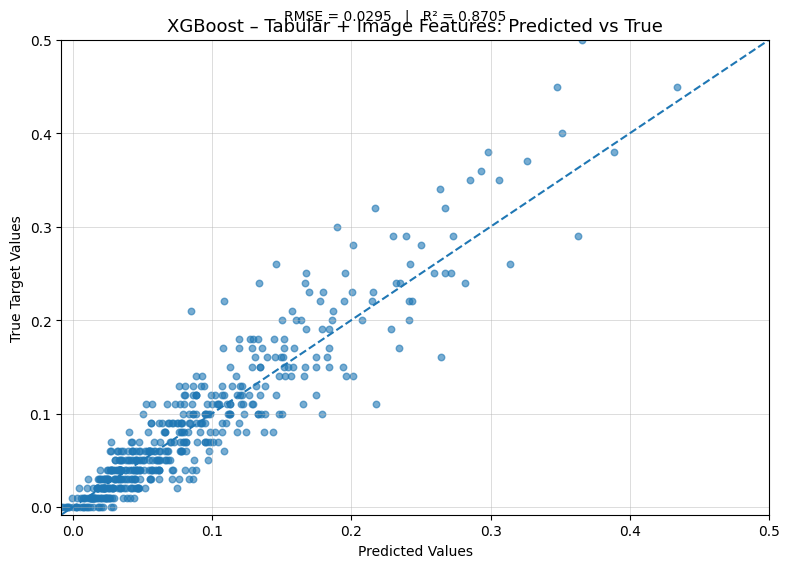

In [45]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
X_train = pd.read_csv(f"{data_path}/X_train.csv")
y_train = pd.read_csv(f"{data_path}/y_train.csv", header=None, names=["risk"])["risk"]
X_test = pd.read_csv(f"{data_path}/X_test.csv")
y_test = pd.read_csv(f"{data_path}/y_test.csv", header=None, names=["risk"])["risk"]
img_train_dir = os.path.join(data_path, "Img_train")
img_test_dir  = os.path.join(data_path, "Img_test")
img_train_files = X_train["img_filename"].tolist()
img_test_files  = X_test["img_filename"].tolist()
X_train = X_train.drop(columns=["img_filename"])  
X_test = X_test.drop(columns=["img_filename"])
# 2) Entraîner le CNN sur les images labellisées
cnn = MyCNN(n_features=64, n_epochs=30, batch_size=32, learning_rate=5e-4)
cnn.fit(img_train_files, y_train.values, data_dir=img_train_dir)


# 3) Extraire les features images pour train et test
img_feat_train = cnn.extract_features(img_train_files, data_dir=img_train_dir)
img_feat_test  = cnn.extract_features(img_test_files,  data_dir=img_test_dir)
scaler_img = StandardScaler()
img_feats_train_scaled = scaler_img.fit_transform(img_feat_train)
img_feats_test_scaled  = scaler_img.transform(img_feat_test)
print("Shapes :")
print("Tabulaire train :", X_train_final.shape)
print("Images train    :", img_feat_train.shape)
print("Tabulaire test  :", X_test_final.shape)
print("Images test     :", img_feat_test.shape)


Xtr_xb = X_train_final[selected_feats].to_numpy()
Xte_xb = X_test_final[selected_feats].to_numpy()

from sklearn.preprocessing import StandardScaler
scaler_img = StandardScaler()
img_feats_train_scaled = scaler_img.fit_transform(img_feat_train)
img_feats_test_scaled  = scaler_img.transform(img_feat_test)

# Concat
X_train_combined = np.concatenate([Xtr_xb, img_feats_train_scaled], axis=1)
X_test_combined  = np.concatenate([Xte_xb, img_feats_test_scaled],  axis=1)





xgb_img = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.8,
    reg_lambda=0,
    reg_alpha=0,
    random_state=42,
    tree_method="hist"
)

xgb_img.fit(X_train_combined, y_train)

y_pred_test_img = xgb_img.predict(X_test_combined)

rmse_img = np.sqrt(mean_squared_error(y_test, y_pred_test_img))
r2_img   = r2_score(y_test, y_pred_test_img)

print(f"\nXGBoost + tabulaire + images : RMSE(test) = {rmse_img:.5f} | R²(test) = {r2_img:.5f}")

plot_pred_vs_true(y_test, y_pred_test_img, 
                  title="XGBoost – Tabular + Image Features: Predicted vs True")




 Testing embedding size n_features = 16
RMSE(test) = 0.0303 | R²(test) = 0.8640

 Testing embedding size n_features = 32
RMSE(test) = 0.0296 | R²(test) = 0.8699

 Testing embedding size n_features = 64
RMSE(test) = 0.0294 | R²(test) = 0.8714

 Testing embedding size n_features = 128
RMSE(test) = 0.0301 | R²(test) = 0.8657


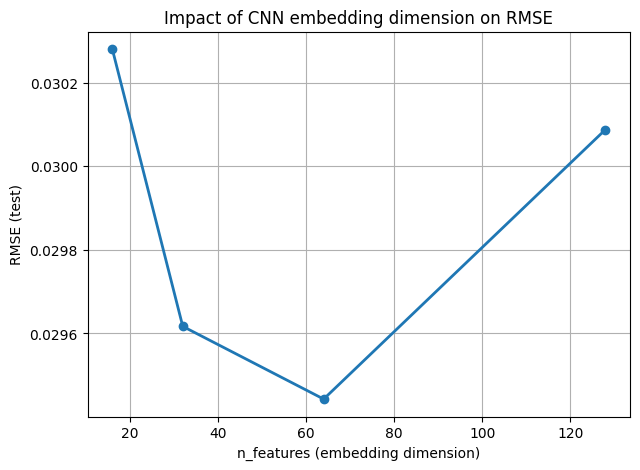

In [38]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

n_values = [16, 32, 64, 128]
rmse_results = []
r2_results = []

for n in n_values:
    print("\n==============================================")
    print(f" Testing embedding size n_features = {n}")
    print("==============================================")

    # 1) Train CNN
    cnn = MyCNN(
        n_features=n,
        n_epochs=25,     
        batch_size=32,
        learning_rate=5e-4
    )
    cnn.fit(img_train_files, y_train.values, data_dir=img_train_dir, verbose=False)

    # 2) Extract image features
    feats_train = cnn.extract_features(img_train_files, data_dir=img_train_dir)
    feats_test  = cnn.extract_features(img_test_files,  data_dir=img_test_dir)

    # Standardisation
    scaler_img = StandardScaler()
    feats_train = scaler_img.fit_transform(feats_train)
    feats_test  = scaler_img.transform(feats_test)
    Xtr_xb = X_train_final[selected_feats].to_numpy()
    Xte_xb = X_test_final[selected_feats].to_numpy()
    # 3) Build combined dataset
    X_train_comb = np.concatenate([Xtr_xb, feats_train], axis=1)
    X_test_comb  = np.concatenate([Xte_xb, feats_test], axis=1)

    # 4) XGBoost on combined features
    model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.8,
    reg_lambda=0,
    reg_alpha=0,
    random_state=42,
    tree_method="hist"
)


    model.fit(X_train_comb, y_train)

    y_pred = model.predict(X_test_comb)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    rmse_results.append(rmse)
    r2_results.append(r2)

    print(f"RMSE(test) = {rmse:.4f} | R²(test) = {r2:.4f}")

# Plot RMSE vs n_features
plt.figure(figsize=(7,5))
plt.plot(n_values, rmse_results, marker='o', linewidth=2)
plt.xlabel("n_features (embedding dimension)")
plt.ylabel("RMSE (test)")
plt.title("Impact of CNN embedding dimension on RMSE")
plt.grid(True)
plt.show()


 Training CNN with n_epochs = 5
RMSE(test) = 0.0383 | R²(test) = 0.7818
 Training CNN with n_epochs = 10
RMSE(test) = 0.0404 | R²(test) = 0.7579
 Training CNN with n_epochs = 15
RMSE(test) = 0.0335 | R²(test) = 0.8337
 Training CNN with n_epochs = 20
RMSE(test) = 0.0324 | R²(test) = 0.8445
 Training CNN with n_epochs = 25
RMSE(test) = 0.0294 | R²(test) = 0.8721
 Training CNN with n_epochs = 30
RMSE(test) = 0.0272 | R²(test) = 0.8901


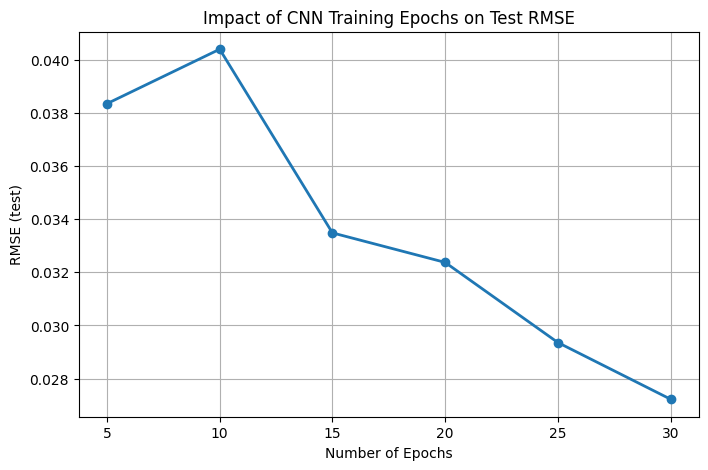

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

epoch_list = [5, 10, 15, 20, 25, 30]
rmse_results = []
r2_results = []

for ne in epoch_list:
    print("="*60)
    print(f" Training CNN with n_epochs = {ne}")
    print("="*60)

    # 1) Train CNN
    cnn = MyCNN(n_features=64, n_epochs=ne, batch_size=32, learning_rate=5e-4)
    cnn.fit(img_train_files, y_train.values, data_dir=img_train_dir, verbose=False)

    # 2) Extract train + test features
    feat_train = cnn.extract_features(img_train_files, img_train_dir)
    feat_test  = cnn.extract_features(img_test_files,  img_test_dir)

    # 3) Scale features
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    feat_train_scaled = scaler.fit_transform(feat_train)
    feat_test_scaled  = scaler.transform(feat_test)

    Xtr_xb = X_train_final[selected_feats].to_numpy()
    Xte_xb = X_test_final[selected_feats].to_numpy()
    # 3) Build combined dataset
    X_train_comb = np.concatenate([Xtr_xb, feat_train_scaled], axis=1)
    X_test_comb  = np.concatenate([Xte_xb,feat_test_scaled ], axis=1)

    # 4) Train XGBoost on top of CNN features
    xgb =  XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.8,
    reg_lambda=0,
    reg_alpha=0,
    random_state=42,
    tree_method="hist"
)
    xgb.fit(X_train_comb, y_train)

    # 5) Prediction
    y_pred = xgb.predict(X_test_comb)

    # 6) RMSE + R²
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    rmse_results.append(rmse)
    r2_results.append(r2)

    print(f"RMSE(test) = {rmse:.4f} | R²(test) = {r2:.4f}")

# === Plot ===
plt.figure(figsize=(8,5))
plt.plot(epoch_list, rmse_results, marker='o', linewidth=2)
plt.xlabel("Number of Epochs")
plt.ylabel("RMSE (test)")
plt.title("Impact of CNN Training Epochs on Test RMSE")
plt.grid(True)
plt.show()


# part 4

## Existe-t-il des groupes clusters à risque élevé ?

risk_group
High Risk      0.124883
Low Risk       0.038363
Medium Risk    0.055597
Name: risk, dtype: float64


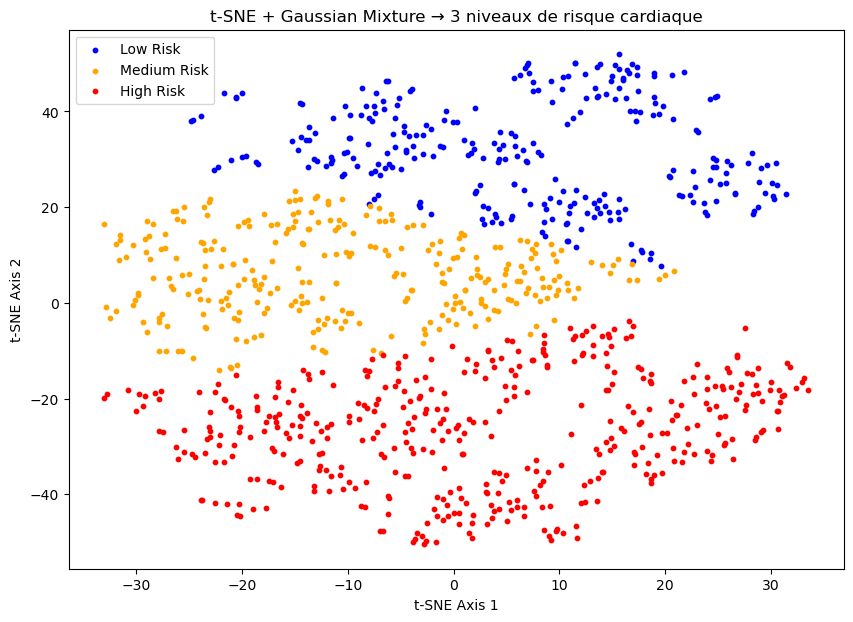

In [75]:
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_combined)  

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
tsne_result = tsne.fit_transform(X_scaled)


gmm = GaussianMixture(n_components=3, random_state=42)
cluster_labels = gmm.fit_predict(tsne_result)

df = pd.DataFrame({
    "tsne1": tsne_result[:,0],
    "tsne2": tsne_result[:,1],
    "risk": y_train,
    "cluster": cluster_labels
})


mean_risk = df.groupby("cluster")["risk"].mean().sort_values()
mapping = {
    mean_risk.index[0]:"Low Risk",
    mean_risk.index[1]:"Medium Risk",
    mean_risk.index[2]:"High Risk"
}
df["risk_group"] = df["cluster"].map(mapping)

print(df.groupby("risk_group")["risk"].mean())

colors = {"Low Risk":"blue", "Medium Risk":"orange", "High Risk":"red"}

plt.figure(figsize=(10,7))
for group,c in colors.items():
    subset = df[df["risk_group"]==group]
    plt.scatter(subset.tsne1, subset.tsne2, s=10, color=c, label=group)

plt.title("t-SNE + Gaussian Mixture : 3 niveaux de risque cardiaque")
plt.legend()
plt.xlabel("t-SNE Axis 1")
plt.ylabel("t-SNE Axis 2")
plt.show()



In [77]:
cluster_stats = pd.concat([df["risk_group"], X_train_final], axis=1)
print(cluster_stats.groupby("risk_group").mean())


                    age  blood pressure   calcium  cholesterol  hemoglobin  \
risk_group                                                                   
High Risk    118.760563      112.681315  2.436925   119.515657   14.146479   
Low Risk     116.338078      104.730178  2.453594   105.264520   14.260890   
Medium Risk  117.160410      105.702662  2.450478   107.523959   14.269113   

               height  potassium  vitamin D      weight  \
risk_group                                                
High Risk    7.597582   4.274296  30.176620  114.585376   
Low Risk     7.617011   4.298897  29.936904   97.584199   
Medium Risk  7.579215   4.383754  30.394573   99.562116   

             profession_administration and governance  ...  \
risk_group                                             ...   
High Risk                                    0.112676  ...   
Low Risk                                     0.032028  ...   
Medium Risk                                  0.078498  ...   

  

## quels facteurs cliniques différencient les groupes ?

C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_22296\2126461634.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Low", "Medium", "High"], showfliers=False)
C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_22296\2126461634.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Low", "Medium", "High"], showfliers=False)
C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_22296\2126461634.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Low", "Medium", "High"], showfliers=False)
C:\Users\ReMarkt\AppData\Local\Temp\ipykernel_22296\2126461634.py:1

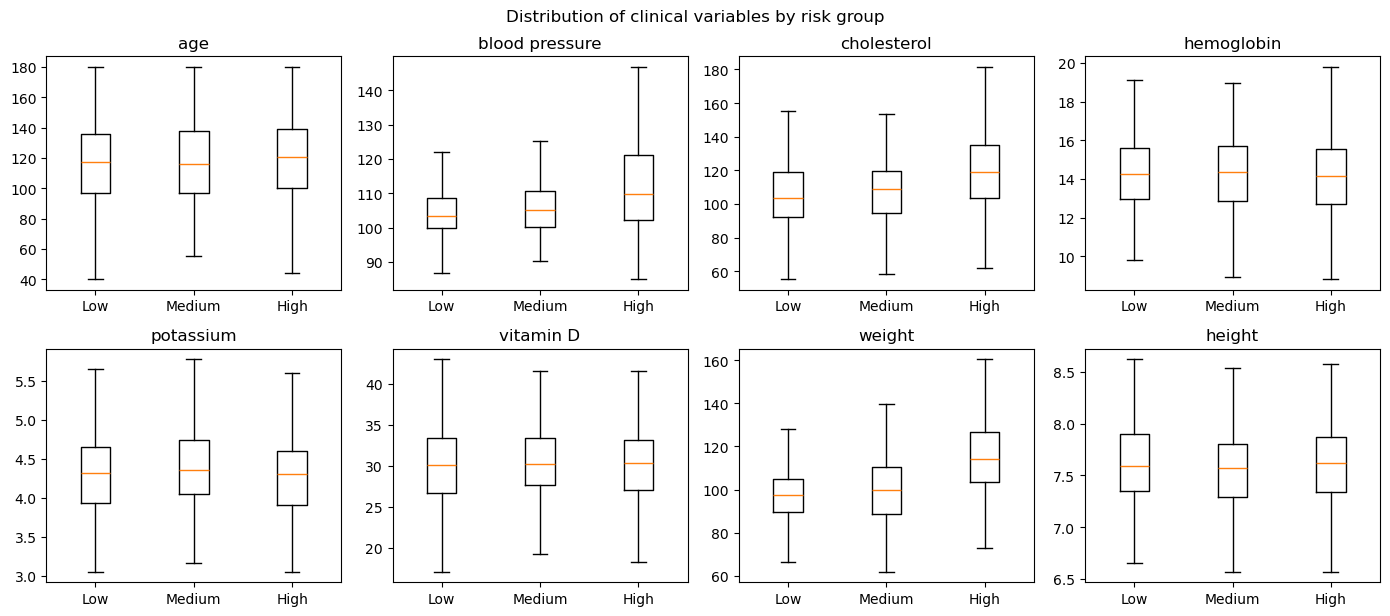

In [137]:
import matplotlib.pyplot as plt
df_all = X_train_final.copy()
df_all["risk"] = y_train.values
df_all["risk_group"] = df["risk_group"]
numeric_cols = ["age", "blood pressure", "cholesterol",
                "hemoglobin", "potassium", "vitamin D", "weight", "height"]

plt.figure(figsize=(14, 6))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 4, i)
    data = [df_all.loc[df_all["risk_group"] == g, col] 
            for g in ["Low Risk", "Medium Risk", "High Risk"]]
    plt.boxplot(data, labels=["Low", "Medium", "High"], showfliers=False)
    plt.title(col)
    plt.tight_layout()

plt.suptitle("Distribution of clinical variables by risk group", y=1.02)
plt.show()

### Visualiser comment l’image du cœur change selon le risque cardiaque

Low risk examples


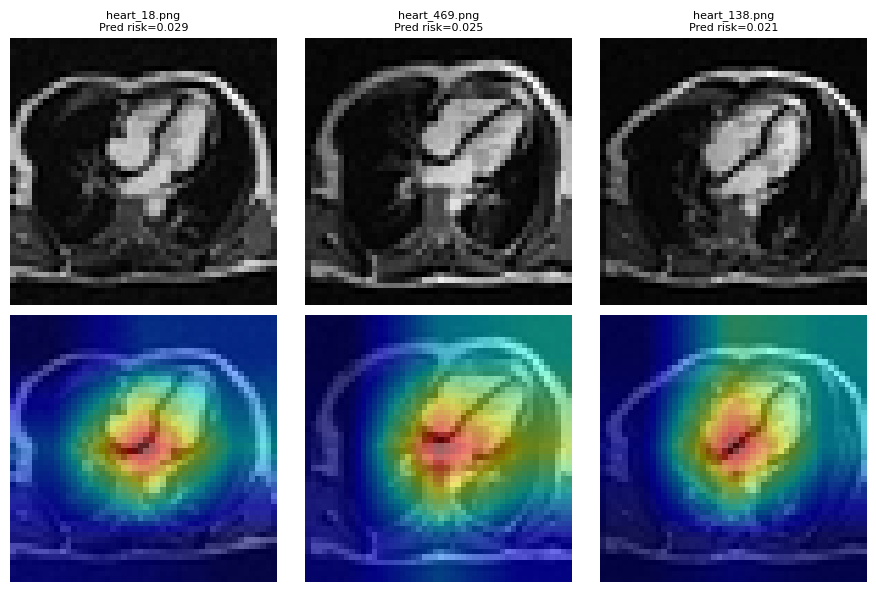

High risk examples


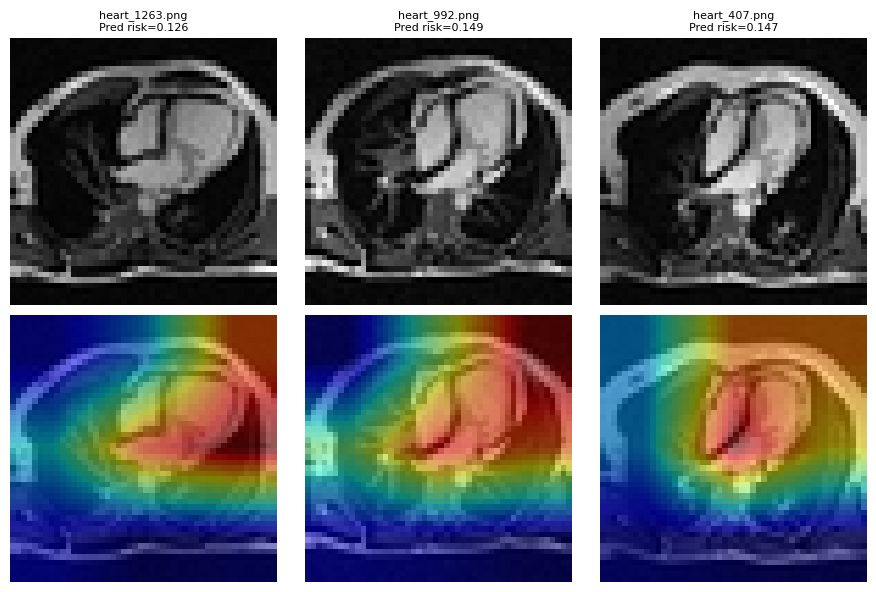

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os




device = next(cnn.model.parameters()).device 


def gradcam_for_image(model, pil_img, data_transform, target=None):
    
    model.eval()
    model.to(device)

 
    x = data_transform(pil_img).unsqueeze(0).to(device)  # (1,1,H,W)

    conv_out = None
    grads = None

   
    def fwd_hook(module, inp, out):
        nonlocal conv_out
        conv_out = out

    def bwd_hook(module, grad_in, grad_out):
        nonlocal grads
        grads = grad_out[0]

    handle_f = model.features.register_forward_hook(fwd_hook)
    handle_b = model.features.register_full_backward_hook(bwd_hook)

    out = model(x)  
    pred = out.item()


    if target is None:
        target = out

    model.zero_grad()
    target.backward(torch.ones_like(out))  

    # On enlève les hooks
    handle_f.remove()
    handle_b.remove()


    A = conv_out[0]        
    G = grads[0]           

    weights = G.mean(dim=(1, 2)) 

    cam = torch.relu((weights[None, :, None, None] * A[None]).sum(1)).squeeze(0)
    cam = F.interpolate(
        cam.unsqueeze(0).unsqueeze(0),
        size=pil_img.size[::-1], 
        mode="bilinear",
        align_corners=False
    ).squeeze()

    cam = cam.detach().cpu().numpy()
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    return pred, cam

def show_gradcam_examples(file_list, model, data_dir, n=6, transform=None):
    
    if transform is None:
       
        transform = transforms.Compose([
            transforms.Grayscale(1),
            transforms.Resize((48, 48)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    n = min(n, len(file_list))
    plt.figure(figsize=(3*n, 6))

    for i, fname in enumerate(file_list[:n]):
        path = os.path.join(data_dir, fname)
        pil = Image.open(path).convert("L")

        pred, cam = gradcam_for_image(model, pil, transform)

        
        ax1 = plt.subplot(2, n, i+1)
        ax1.imshow(pil, cmap="gray")
        ax1.set_title(f"{fname}\nPred risk={pred:.3f}", fontsize=8)
        ax1.axis("off")

        
        ax2 = plt.subplot(2, n, n+i+1)
        ax2.imshow(pil, cmap="gray")
order = np.argsort(y_train.values)

low_idx  = order[:3]
high_idx = order[-3:]

img_train_files = np.array(img_train_files)   

low_files  = img_train_files[low_idx]
high_files = img_train_files[high_idx]

print("Low risk examples")
show_gradcam_examples(low_files, cnn.model, img_train_dir, n=3)

print("High risk examples")
show_gradcam_examples(high_files, cnn.model, img_train_dir, n=3)
   
order = np.argsort(y_train.values)

low_idx  = order[:3]
high_idx = order[-3:]







Pour les Smurfs à risque cardiaque élevé, le modèle se focalise sur les zones présentant des déformations, perte de contraste ou dilatation du ventricule.
 Le modèle semble considérer qu’un ventricule visuellement homogène et bien délimité correspond à un risque faible.